## Importing Data Files

In [16]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna

In [17]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')

print("Path to competition files:", path)

Path to competition files: C:\Users\EthanYongYuHeng\.cache\kagglehub\competitions\playground-series-s6e5


In [18]:

train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")

print(train.head())

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0      39.0         8       78.491         -7.564                  21.019   
1       7.0         4       75.095        -32.617                -223.207   
2      22.0        13       70.945         -7.540                -100.529   
3       2.0         7       94.361         -7.324                  -7.324   
4       6.0         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change  PitNextLap  
0  

In [19]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

## Variable Categories
| Column                   | Type                             | Why                                  |
| ------------------------ | -------------------------------- | ------------------------------------ |
| `id`                     | Identifier                       | Unique row ID, not useful as feature |
| `Driver`                 | Categorical (nominal)            | Driver names/codes                   |
| `Compound`               | Categorical (nominal)            | HARD / MEDIUM / SOFT etc.            |
| `Race`                   | Categorical (nominal)            | Race/event name                      |
| `Year`                   | Numerical (discrete)             | Ordered integer year                 |
| `PitStop`                | Binary categorical               | 0 or 1                               |
| `LapNumber`              | Numerical (discrete ordinal)     | Ordered lap progression              |
| `Stint`                  | Ordinal categorical              | Ordered tyre stint number            |
| `TyreLife`               | Numerical (discrete)             | Tyre age in laps                     |
| `Position`               | Ordinal numerical                | Race ranking position                |
| `LapTime (s)`            | Numerical (continuous)           | Continuous time value                |
| `LapTime_Delta`          | Numerical (continuous)           | Difference in lap performance        |
| `Cumulative_Degradation` | Numerical (continuous)           | Engineered degradation metric        |
| `RaceProgress`           | Numerical (continuous)           | Normalized race percentage           |
| `Position_Change`        | Numerical (discrete signed)      | Gain/loss of positions               |
| `PitNextLap`             | Binary categorical (target-like) | Future pit indicator                 |


In [20]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


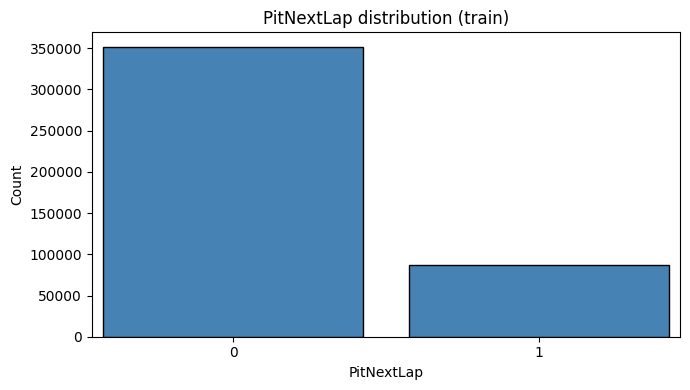

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64


In [21]:


fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    train["PitNextLap"],
    bins=np.arange(-0.5, 2, 1),
    edgecolor="black",
    rwidth=0.85,
    color="steelblue",
)
ax.set_xticks([0, 1])
ax.set_xlabel("PitNextLap")
ax.set_ylabel("Count")
ax.set_title("PitNextLap distribution (train)")
ax.margins(x=0.02)
plt.tight_layout()
plt.show()

print(train["PitNextLap"].value_counts(normalize=True).sort_index().rename("proportion"))

## **Target Variable Distribution — `PitNextLap`**

This shows that the dataset is **moderately imbalanced**, with **non-pit-stop laps** occurring approximately **four times more frequently** than pit-stop laps. Such imbalance is expected in Formula 1 race data because drivers spend the majority of laps remaining on track rather than entering the pits.

Due to this imbalance, relying solely on **accuracy** as an evaluation metric may produce misleading results. For example, a model that always predicts **“no pit stop”** would already achieve around **80% accuracy** despite completely failing to identify actual pit-stop events.

---

#  **Proposed Approach**

To address the class imbalance and build a reliable **pit stop prediction model**, the following approach will be used:

---

##  **1. Imbalance Handling**

Instead of immediately applying oversampling or undersampling techniques, **class weighting methods** will first be used so that pit-stop instances receive greater importance during training.

Examples include:

- **`class_weight="balanced"`** for sklearn-based models
- **`scale_pos_weight ≈ 4`** for boosting models such as **XGBoost** or **LightGBM**

This approach allows the model to learn minority-class patterns more effectively **without discarding valuable data** or generating synthetic samples.

---

##  **2. Model Selection**

Several **tree-based ensemble models** will be explored due to their strong performance on structured and tabular datasets:

- **XGBoost**
- **LightGBM**
- **Random Forest**

These models are well-suited for capturing complex race strategy patterns and non-linear relationships within the data.

---

##  **3. Evaluation Metrics**

Since **accuracy alone is insufficient** for imbalanced classification problems, evaluation will focus on more informative metrics such as:

- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Confusion Matrix**

Special emphasis will be placed on **Recall** and **F1-score** for the pit-stop class to ensure the model can effectively identify actual pit-stop opportunities.

---

##  **4. Data Splitting Strategy**

To prevent **data leakage**, the dataset will **not** be randomly split by laps. Instead, the data will be divided either:

- **By race**, or
- **Chronologically**

This preserves the natural sequence of race events and ensures a more realistic evaluation of model performance in real-world race scenarios.

In [22]:
train.describe(include="all")

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140,439140,439140,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
unique,NaN,887,5,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,MAS,MEDIUM,Dutch Grand Prix,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1682,211141,24462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,219569.500000,NaN,NaN,NaN,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,NaN,NaN,NaN,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,NaN,NaN,NaN,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,NaN,NaN,NaN,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,NaN,NaN,NaN,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,NaN,NaN,NaN,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000


In [23]:
## Feature Engineering

# Make copies to preserve original data
train_fe = train.copy()
test_fe = test.copy()

# Combine temporarily for consistent feature engineering
combined = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

# Drop Unused Columns 
combined.drop(columns=["id"], inplace=True)


## TYRE LIFE FEATURES

# Tyre wear category based on dataset distribution
combined["TyreWearCategory"] = pd.cut(
    combined["TyreLife"],
    bins=[0, 8, 18, 35, 80],
    labels=["Fresh", "Medium", "Old", "Critical"]
)

# Tyre life normalized
combined["TyreLife_Normalized"] = (
    combined["TyreLife"] / combined["TyreLife"].max()
)

# Degradation per tyre lap
combined["DegPerLap"] = (
    combined["Cumulative_Degradation"] /
    (combined["TyreLife"] + 1e-5)
)

## RACE PPHASE FEATURES

combined["RacePhase"] = pd.cut(
    combined["RaceProgress"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Early", "Mid", "Late"]
)

# Late race indicator
combined["LateRace"] = (
    combined["RaceProgress"] >= 0.7
).astype(int)

## POSITION FEATURES

# Top 10 / points scoring zone
combined["PointsZone"] = (
    combined["Position"] <= 10
).astype(int)

# Podium position
combined["PodiumPosition"] = (
    combined["Position"] <= 3
).astype(int)

# Backmarker indicator
combined["Backmarker"] = (
    combined["Position"] >= 16
).astype(int)

# POSITION CHANGE FEATURES

# Losing positions
combined["LosingPositions"] = (
    combined["Position_Change"] < 0
).astype(int)

# Gaining positions
combined["GainingPositions"] = (
    combined["Position_Change"] > 0
).astype(int)

# Large position swings
combined["LargePositionChange"] = (
    combined["Position_Change"].abs() >= 5
).astype(int)


## STINT FEATURES

# Late stint indicator
combined["LateStint"] = (
    combined["Stint"] >= 3
).astype(int)

# Long stint indicator
combined["LongStintTyres"] = (
    combined["TyreLife"] >= 20
).astype(int)

## LAP TIME FEATURES

# Rolling lap time average by driver
combined["RollingLapTime_3"] = (
    combined.groupby("Driver")["LapTime (s)"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling lap delta average
combined["RollingLapDelta_3"] = (
    combined.groupby("Driver")["LapTime_Delta"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Pace drop indicator
combined["PerformanceDrop"] = (
    combined["LapTime_Delta"] > 2
).astype(int)

# Severe pace drop indicator
combined["SeverePerformanceDrop"] = (
    combined["LapTime_Delta"] > 5
).astype(int)


## OUTLIER HANDLING

# Cap extreme lap times
combined["LapTime (s)"] = combined["LapTime (s)"].clip(
    lower=60,
    upper=300
)

# Cap LapTime_Delta
combined["LapTime_Delta"] = combined["LapTime_Delta"].clip(
    lower=-60,
    upper=60
)

# Cap cumulative degradation
combined["Cumulative_Degradation"] = combined[
    "Cumulative_Degradation"
].clip(
    lower=-300,
    upper=300
)



## Split back to Train/Test result

In [24]:
train_fe = combined.iloc[:len(train)].copy()
test_fe = combined.iloc[len(train):].copy()

print("Train Shape:", train_fe.shape)
print("Test Shape:", test_fe.shape)

print(train_fe.head())

Train Shape: (439140, 32)
Test Shape: (188165, 32)
  Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  ...  Backmarker  LosingPositions  \
0      39.0         8       78.491  ...           0                0   
1       7.0         4       75.095  ...           0                1   
2      22.0        13       70.945  ...           0                0   
3       2.0         7       94.361  ...           0                0   
4       6.0         2      107.878  ...           0                0   

   GainingPositions  LargePositionChange  LateStint L

## Label and Target Encoding

- **Label encoding** (`*_le`): integer codes per category, fit on train only.
- **Target encoding** (`*_te`): smoothed train pit-stop rate per category for `Driver`, `Race`, and `Compound` (no test labels used).
- One-hot dummies were removed to reduce sparse high-dimensional features.

In [25]:
categorical_cols = ["Driver", "Compound", "Race", "TyreWearCategory", "RacePhase"]
target_encode_cols = ["Driver", "Race", "Compound"]
SMOOTH = 10

# Label encoding (fit on train, apply to test)
le = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
le_cols = [c + "_le" for c in categorical_cols]
train_fe[le_cols] = le.fit_transform(train_fe[categorical_cols])
test_fe[le_cols] = le.transform(test_fe[categorical_cols])

# Target encoding (train PitNextLap only)
global_mean = train_fe["PitNextLap"].mean()
for col in target_encode_cols:
    stats = train_fe.groupby(col)["PitNextLap"].agg(["mean", "count"])
    stats["smooth"] = (
        stats["count"] * stats["mean"] + SMOOTH * global_mean
    ) / (stats["count"] + SMOOTH)
    mapping = stats["smooth"]
    train_fe[col + "_te"] = train_fe[col].map(mapping).fillna(global_mean)
    test_fe[col + "_te"] = test_fe[col].map(mapping).fillna(global_mean)

train_fe.drop(columns=categorical_cols, inplace=True)
test_fe.drop(columns=categorical_cols, inplace=True)

print("Train shape after encoding:", train_fe.shape)
print("Test shape after encoding:", test_fe.shape)
print("Sample encoded columns:", le_cols + [c + "_te" for c in target_encode_cols])
train_fe[le_cols + [c + "_te" for c in target_encode_cols]].head()

Train shape after encoding: (439140, 35)
Test shape after encoding: (188165, 35)
Sample encoded columns: ['Driver_le', 'Compound_le', 'Race_le', 'TyreWearCategory_le', 'RacePhase_le', 'Driver_te', 'Race_te', 'Compound_te']


,Driver_le,Compound_le,Race_le,TyreWearCategory_le,RacePhase_le,Driver_te,Race_te,Compound_te
0,134.0,0.0,7.0,0.0,1.0,0.200952,0.153878,0.327530
1,111.0,0.0,9.0,1.0,2.0,0.191876,0.176078,0.327530
2,886.0,0.0,2.0,3.0,1.0,0.228468,0.188056,0.327530
3,864.0,2.0,19.0,1.0,0.0,0.194168,0.146564,0.101136
4,44.0,0.0,3.0,1.0,2.0,0.192353,0.214567,0.327530


## Separate Features and Target for Model Training

In [26]:
## Ensure train and test have same number and order of columns after encoding

train_fe, test_fe = train_fe.align(
    test_fe,
    join="left",
    axis=1,
    fill_value=0
)

In [27]:
X = train_fe.drop(columns=["PitNextLap"])
y = train_fe["PitNextLap"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Feature Preprocessing

Variance filtering, low target-correlation removal, high multicollinearity removal, and `StandardScaler` are fit on `X_train` only, then applied to `X_valid` and (later) the test set.

In [28]:
# --- Config (tune as needed) ---
VAR_THRESHOLD = 0.0
MIN_TARGET_CORR = 0.01
MAX_FEATURE_CORR = 0.95

RAW_FEATURE_COLS = X.columns.tolist()
n_features_start = len(RAW_FEATURE_COLS)


def fit_variance_filter(X, threshold=0.0):
    vt = VarianceThreshold(threshold=threshold)
    vt.fit(X)
    mask = vt.get_support()
    return X.columns[mask].tolist()


def fit_low_target_corr(X, y, cols, min_corr):
    target_corr = X[cols].corrwith(y).abs()
    return target_corr[target_corr >= min_corr].index.tolist()


def fit_multicollinearity(X, y, cols, max_corr):
    remaining = list(cols)
    target_corr = X[remaining].corrwith(y).abs()

    while True:
        if len(remaining) <= 1:
            break
        corr = X[remaining].corr().abs()
        upper = corr.where(
            np.triu(np.ones(corr.shape), k=1).astype(bool)
        )
        pairs = (
            upper.stack()
            .reset_index()
            .rename(columns={"level_0": "a", "level_1": "b", 0: "corr"})
        )
        high = pairs[pairs["corr"] > max_corr]
        if high.empty:
            break
        row = high.loc[high["corr"].idxmax()]
        drop_col = (
            row["a"]
            if target_corr[row["a"]] < target_corr[row["b"]]
            else row["b"]
        )
        remaining.remove(drop_col)
        target_corr = target_corr.drop(drop_col)

    return remaining


# 1) Variance filter
var_cols = fit_variance_filter(X_train, threshold=VAR_THRESHOLD)
n_dropped_var = n_features_start - len(var_cols)

# 2) Low target correlation
corr_cols = fit_low_target_corr(
    X_train, y_train, var_cols, MIN_TARGET_CORR
)
n_dropped_low_corr = len(var_cols) - len(corr_cols)
low_corr_dropped = sorted(set(var_cols) - set(corr_cols))

# 3) Multicollinearity
SELECTED_FEATURES = fit_multicollinearity(
    X_train, y_train, corr_cols, MAX_FEATURE_CORR
)
n_dropped_multicoll = len(corr_cols) - len(SELECTED_FEATURES)

if not SELECTED_FEATURES:
    raise ValueError(
        "All features were removed. Lower MIN_TARGET_CORR or relax other thresholds."
    )

# 4) StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[SELECTED_FEATURES])

X_train = pd.DataFrame(
    scaler.transform(X_train[SELECTED_FEATURES]),
    columns=SELECTED_FEATURES,
    index=X_train.index,
)
X_valid = pd.DataFrame(
    scaler.transform(X_valid[SELECTED_FEATURES]),
    columns=SELECTED_FEATURES,
    index=X_valid.index,
)


def transform_preprocessed(df):
    return pd.DataFrame(
        scaler.transform(df[SELECTED_FEATURES]),
        columns=SELECTED_FEATURES,
        index=df.index,
    )


print(f"Features: {n_features_start} -> {len(SELECTED_FEATURES)}")
print(f"  Dropped (variance): {n_dropped_var}")
print(f"  Dropped (low |target corr| < {MIN_TARGET_CORR}): {n_dropped_low_corr}")
print(f"  Dropped (multicollinearity > {MAX_FEATURE_CORR}): {n_dropped_multicoll}")
print(f"Train shape after preprocessing: {X_train.shape}")
print(f"Valid shape after preprocessing: {X_valid.shape}")
if low_corr_dropped:
    print(f"Sample low-corr dropped: {low_corr_dropped[:10]}")

Features: 34 -> 28
  Dropped (variance): 0
  Dropped (low |target corr| < 0.01): 4
  Dropped (multicollinearity > 0.95): 2
Train shape after preprocessing: (351312, 28)
Valid shape after preprocessing: (87828, 28)
Sample low-corr dropped: ['Backmarker', 'DegPerLap', 'Race_le', 'RollingLapDelta_3']


## Hyperparameter Tuning (Optuna)

Three separate Optuna studies (`direction="maximize"`) tune **Random Forest**, **XGBoost**, and **LightGBM** on `X_train` using stratified 5-fold CV. The objective is mean **F1 (class 1)** so models learn pit-stop signal under imbalance. **Decision thresholds** are tuned separately on OOF predictions for F1 and accuracy later. `X_valid` is held out until final model evaluation.

Random Forest uses a **light search** (only `n_estimators` and `max_depth`) because full RF tuning is slow with 5-fold CV.


In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

N_SPLITS = 5
RANDOM_STATE = 42
N_TRIALS = 100  # use 5-10 for quick dry-runs

CV_FOLDS = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def cv_f1_class1(model, X, y) -> float:
    scores = []
    for tr_idx, val_idx in CV_FOLDS.split(X, y):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = model.predict(X.iloc[val_idx])
        scores.append(
            f1_score(y.iloc[val_idx], pred, pos_label=1, zero_division=0)
        )
    return float(np.mean(scores))


# --- Random Forest (light search: only n_estimators + max_depth) ---
def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 250),
        max_depth=trial.suggest_int("max_depth", 8, 16),
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return cv_f1_class1(model, X_train, y_train)


study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="random_forest",
)
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)
rf_best_params = study_rf.best_params.copy()
print("Random Forest best CV F1:", study_rf.best_value)
print("Random Forest best params:", rf_best_params)


# --- XGBoost ---
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 2.0, 6.0),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model = XGBClassifier(**params)
    return cv_f1_class1(model, X_train, y_train)


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(),
    study_name="xgboost",
)
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
xgb_best_params = study_xgb.best_params.copy()
print("XGBoost best CV F1:", study_xgb.best_value)
print("XGBoost best params:", xgb_best_params)


# --- LightGBM ---
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 16, 127),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": scale_pos_weight,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    return cv_f1_class1(model, X_train, y_train)


study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(),
    study_name="lightgbm",
)
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
lgbm_best_params = study_lgbm.best_params.copy()
print("LightGBM best CV F1:", study_lgbm.best_value)
print("LightGBM best params:", lgbm_best_params)

optuna_results = pd.DataFrame(
    [
        {"Model": "Random Forest", "CV F1 (class 1)": study_rf.best_value, **rf_best_params},
        {"Model": "XGBoost", "CV F1 (class 1)": study_xgb.best_value, **xgb_best_params},
        {"Model": "LightGBM", "CV F1 (class 1)": study_lgbm.best_value, **lgbm_best_params},
    ]
)
optuna_results
                            

[I 2026-05-25 14:37:19,814] A new study created in memory with name: random_forest


  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-05-25 14:40:31,497] Trial 0 failed with parameters: {'n_estimators': 156, 'max_depth': 16} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\EthanYongYuHeng\Desktop\F1-pitstop-prediction\venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\EthanYongYuHeng\AppData\Local\Temp\ipykernel_41564\3799405629.py", line 36, in objective_rf
    return cv_f1_class1(model, X_train, y_train)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\EthanYongYuHeng\AppData\Local\Temp\ipykernel_41564\3799405629.py", line 18, in cv_f1_class1
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
  File "c:\Users\EthanYongYuHeng\Desktop\F1-pitstop-prediction\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Et

KeyboardInterrupt: 

## Random Forest Classifier

In [ ]:
model = RandomForestClassifier(
    **rf_best_params,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",229
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

model_results = []


def record_model_metrics(name, y_true, y_pred, y_prob):
    model_results.append({
        "Model": name,
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision (class 1)": float(
            precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        ),
        "Recall (class 1)": float(
            recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        ),
        "F1 (class 1)": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, y_prob)),
        "PR-AUC": float(average_precision_score(y_true, y_prob)),
    })

y_pred = model.predict(X_valid)
y_prob = model.predict_proba(X_valid)[:, 1]

record_model_metrics("Random Forest", y_valid, y_pred, y_prob)

print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_valid, y_prob))

              precision    recall  f1-score   support

         0.0       0.96      0.89      0.92     70352
         1.0       0.65      0.84      0.73     17476

    accuracy                           0.88     87828
   macro avg       0.80      0.86      0.83     87828
weighted avg       0.90      0.88      0.88     87828

[[62319  8033]
 [ 2808 14668]]
ROC-AUC Score: 0.9384555210920406


## XGBoost Model

In [ ]:
# Create XGBoost model (Optuna-tuned hyperparameters)
xgb_model = XGBClassifier(
    **xgb_best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Train model
xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9368457282848106
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [ ]:
# Predict
y_pred = xgb_model.predict(X_valid)
y_prob = xgb_model.predict_proba(X_valid)[:, 1]

record_model_metrics("XGBoost", y_valid, y_pred, y_prob)

# Evaluation
print(classification_report(y_valid, y_pred))

print(confusion_matrix(y_valid, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_valid, y_prob))

              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93     70352
         1.0       0.70      0.82      0.75     17476

    accuracy                           0.89     87828
   macro avg       0.83      0.87      0.84     87828
weighted avg       0.90      0.89      0.90     87828

[[64132  6220]
 [ 3147 14329]]
ROC-AUC Score: 0.9479653637402745


## Feature Importance

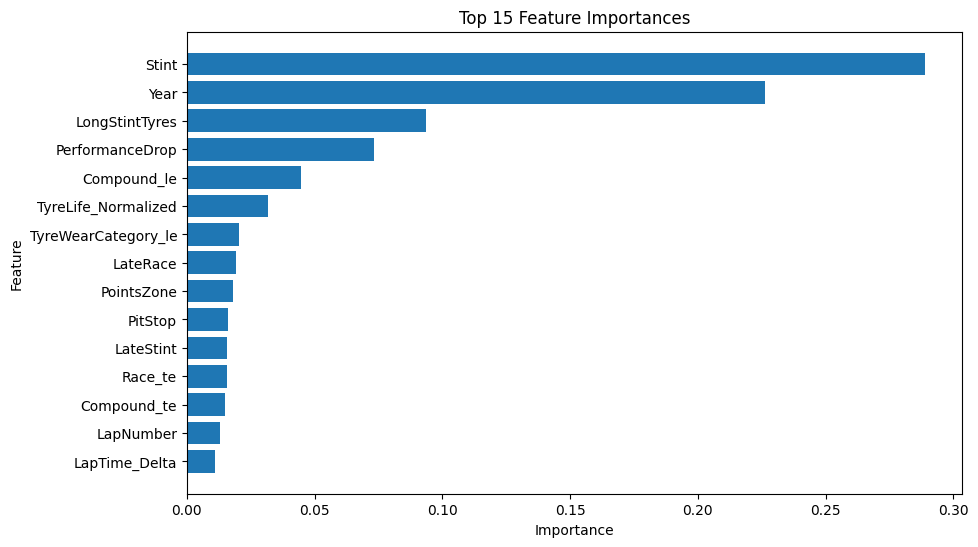

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

## LightBGM

In [ ]:
# Handle imbalance (fixed from training split)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Create model (Optuna-tuned hyperparameters)
lgbm_model = LGBMClassifier(
    **lgbm_best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

# Train
lgbm_model.fit(X_train, y_train)


,boosting_type,'gbdt'
,num_leaves,122
,max_depth,11
,learning_rate,0.14234141032569764
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# Predict
y_pred = lgbm_model.predict(X_valid)
y_prob = lgbm_model.predict_proba(X_valid)[:, 1]

record_model_metrics("LightGBM", y_valid, y_pred, y_prob)

# Evaluation
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_valid, y_prob))


              precision    recall  f1-score   support

         0.0       0.96      0.88      0.92     70352
         1.0       0.65      0.87      0.74     17476

    accuracy                           0.88     87828
   macro avg       0.81      0.88      0.83     87828
weighted avg       0.90      0.88      0.89     87828

[[62069  8283]
 [ 2258 15218]]
ROC-AUC Score: 0.9459622429718488


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score

THRESHOLD_GRID = np.arange(0.05, 0.96, 0.01)
SUBMISSION_THRESHOLD_OBJECTIVE = "accuracy"  # or "f1"
N_SPLITS = 5
RANDOM_STATE = 42

OOF_SKF = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def tune_threshold(y_true, probs, grid, metric="f1"):
    if metric == "f1":
        metric_fn = lambda yt, pred: f1_score(yt, pred, zero_division=0)
    elif metric == "accuracy":
        metric_fn = lambda yt, pred: accuracy_score(yt, pred)
    else:
        raise ValueError(f"Unknown metric: {metric!r}")
    scores = [metric_fn(y_true, (probs >= t).astype(int)) for t in grid]
    best_idx = int(np.argmax(scores))
    return float(grid[best_idx]), float(scores[best_idx]), scores


def generate_oof_proba(model_factory, X, y, skf, label=""):
    oof = np.zeros(len(y), dtype=float)
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        fold_model = model_factory()
        fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof[val_idx] = fold_model.predict_proba(X.iloc[val_idx])[:, 1]
        print(f"{label} fold {fold}/{skf.n_splits} complete")
    return oof


def build_threshold_leaderboard(y_true, probs, grid, f1_scores, acc_scores):
    return pd.DataFrame(
        {
            "threshold": grid,
            "accuracy": acc_scores,
            "f1_class_1": f1_scores,
            "precision_class_1": [
                precision_score(y_true, probs >= t, zero_division=0)
                for t in grid
            ],
            "recall_class_1": [
                recall_score(y_true, probs >= t, zero_division=0)
                for t in grid
            ],
        }
    )


def print_oof_threshold_comparison(model_label, oof_probs, y_true, t_f1, f1_at_t, t_acc, acc_at_t):
    pred_f1 = (oof_probs >= t_f1).astype(int)
    pred_acc = (oof_probs >= t_acc).astype(int)
    print()
    print(f"=== {model_label}: OOF threshold comparison ===")
    print(f"F1 threshold:       {t_f1:.2f}  |  OOF F1: {f1_at_t:.4f}  |  OOF accuracy: {accuracy_score(y_true, pred_f1):.4f}")
    print(f"Accuracy threshold: {t_acc:.2f}  |  OOF accuracy: {acc_at_t:.4f}  |  OOF F1: {f1_score(y_true, pred_acc, zero_division=0):.4f}")
    print(
        f"roc_auc={roc_auc_score(y_true, oof_probs):.4f}, "
        f"pr_auc={average_precision_score(y_true, oof_probs):.4f}"
    )


def validation_threshold_summary(y_valid, probs, t_f1, t_acc):
    rows = []
    for objective, t in [("default", 0.50), ("f1", t_f1), ("accuracy", t_acc)]:
        pred = (probs >= t).astype(int)
        rows.append(
            {
                "objective": objective,
                "threshold": t,
                "accuracy": accuracy_score(y_valid, pred),
                "precision_class_1": precision_score(y_valid, pred, zero_division=0),
                "recall_class_1": recall_score(y_valid, pred, zero_division=0),
                "f1_class_1": f1_score(y_valid, pred, zero_division=0),
                "roc_auc": roc_auc_score(y_valid, probs),
                "pr_auc": average_precision_score(y_valid, probs),
            }
        )
    return pd.DataFrame(rows).round(4)


def replace_model_metrics(name, y_true, y_pred, y_prob):
    for i, row in enumerate(model_results):
        if row["Model"] == name:
            model_results[i] = {
                "Model": name,
                "Accuracy": float(accuracy_score(y_true, y_pred)),
                "Precision (class 1)": float(
                    precision_score(y_true, y_pred, pos_label=1, zero_division=0)
                ),
                "Recall (class 1)": float(
                    recall_score(y_true, y_pred, pos_label=1, zero_division=0)
                ),
                "F1 (class 1)": float(
                    f1_score(y_true, y_pred, pos_label=1, zero_division=0)
                ),
                "ROC-AUC": float(roc_auc_score(y_true, y_prob)),
                "PR-AUC": float(average_precision_score(y_true, y_prob)),
            }
            return
    record_model_metrics(name, y_true, y_pred, y_prob)


## Multi-Model OOF + Threshold Tuning

Out-of-fold (OOF) probabilities are generated on `X_train` with 5-fold stratified CV using Optuna-tuned hyperparameters for **Random Forest**, **XGBoost**, and **LightGBM**.

Decision thresholds are tuned on OOF predictions two ways: **F1 (class 1)** and **accuracy**. Accuracy thresholds align with the Kaggle scoring metric; F1 thresholds remain for pit-stop recall analysis. Tuned thresholds are applied to full-fit models on `X_valid` without retraining.


In [ ]:
RF_PARAMS = {
    **rf_best_params,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
XGB_PARAMS = {
    **xgb_best_params,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
LGBM_PARAMS = {
    **lgbm_best_params,
    "scale_pos_weight": scale_pos_weight,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

print("Generating OOF probabilities (5-fold stratified CV)...")
rf_oof_probs = generate_oof_proba(
    lambda: RandomForestClassifier(**RF_PARAMS),
    X_train,
    y_train,
    OOF_SKF,
    label="Random Forest",
)
xgb_oof_probs = generate_oof_proba(
    lambda: XGBClassifier(**XGB_PARAMS),
    X_train,
    y_train,
    OOF_SKF,
    label="XGBoost",
)
lgbm_oof_probs = generate_oof_proba(
    lambda: LGBMClassifier(**LGBM_PARAMS),
    X_train,
    y_train,
    OOF_SKF,
    label="LightGBM",
)

for label, oof in [
    ("Random Forest", rf_oof_probs),
    ("XGBoost", xgb_oof_probs),
    ("LightGBM", lgbm_oof_probs),
]:
    covered = int(np.isfinite(oof).sum())
    print(f"{label} OOF coverage: {covered} / {len(oof)}")

# --- Threshold tuning per model ---
(
    rf_best_threshold_f1,
    rf_best_oof_f1,
    rf_f1_scores,
) = tune_threshold(y_train, rf_oof_probs, THRESHOLD_GRID, metric="f1")
(
    rf_best_threshold_acc,
    rf_best_oof_acc,
    rf_acc_scores,
) = tune_threshold(y_train, rf_oof_probs, THRESHOLD_GRID, metric="accuracy")

(
    xgb_best_threshold_f1,
    xgb_best_oof_f1,
    xgb_f1_scores,
) = tune_threshold(y_train, xgb_oof_probs, THRESHOLD_GRID, metric="f1")
(
    xgb_best_threshold_acc,
    xgb_best_oof_acc,
    xgb_acc_scores,
) = tune_threshold(y_train, xgb_oof_probs, THRESHOLD_GRID, metric="accuracy")

(
    lgbm_best_threshold_f1,
    lgbm_best_oof_f1,
    lgbm_f1_scores,
) = tune_threshold(y_train, lgbm_oof_probs, THRESHOLD_GRID, metric="f1")
(
    lgbm_best_threshold_acc,
    lgbm_best_oof_acc,
    lgbm_acc_scores,
) = tune_threshold(y_train, lgbm_oof_probs, THRESHOLD_GRID, metric="accuracy")

for model_label, oof_probs, t_f1, f1_at_t, t_acc, acc_at_t in [
    ("Random Forest", rf_oof_probs, rf_best_threshold_f1, rf_best_oof_f1, rf_best_threshold_acc, rf_best_oof_acc),
    ("XGBoost", xgb_oof_probs, xgb_best_threshold_f1, xgb_best_oof_f1, xgb_best_threshold_acc, xgb_best_oof_acc),
    ("LightGBM", lgbm_oof_probs, lgbm_best_threshold_f1, lgbm_best_oof_f1, lgbm_best_threshold_acc, lgbm_best_oof_acc),
]:
    print_oof_threshold_comparison(model_label, oof_probs, y_train, t_f1, f1_at_t, t_acc, acc_at_t)

rf_valid_probs = model.predict_proba(X_valid)[:, 1]
xgb_valid_probs = xgb_model.predict_proba(X_valid)[:, 1]
lgbm_valid_probs = lgbm_model.predict_proba(X_valid)[:, 1]

single_model_thresholds = [
    ("Random Forest", rf_valid_probs, rf_best_threshold_f1, rf_best_threshold_acc),
    ("XGBoost", xgb_valid_probs, xgb_best_threshold_f1, xgb_best_threshold_acc),
    ("LightGBM", lgbm_valid_probs, lgbm_best_threshold_f1, lgbm_best_threshold_acc),
]

for model_label, valid_probs, t_f1, t_acc in single_model_thresholds:
    print()
    print(f"=== {model_label}: validation threshold summary ===")
    display(validation_threshold_summary(y_valid, valid_probs, t_f1, t_acc))

    pred_acc = (valid_probs >= t_acc).astype(int)
    replace_model_metrics(model_label, y_valid, pred_acc, valid_probs)

OOF_THRESHOLDS_F1 = {
    "Random Forest": rf_best_threshold_f1,
    "XGBoost": xgb_best_threshold_f1,
    "LightGBM": lgbm_best_threshold_f1,
}
OOF_THRESHOLDS_ACC = {
    "Random Forest": rf_best_threshold_acc,
    "XGBoost": xgb_best_threshold_acc,
    "LightGBM": lgbm_best_threshold_acc,
}


## Ensemble (Blend + Stack)

Combine OOF probabilities from all three tuned models via **equal blend**, **Optuna-weighted blend** (weights tuned on OOF accuracy), and **LogisticRegression stacking**.

Thresholds on ensemble OOF probabilities are tuned for both F1 and accuracy. Validation metrics use accuracy-optimal thresholds for fair comparison with the Kaggle metric.


In [ ]:
from sklearn.linear_model import LogisticRegression

# --- Equal blend ---
blend_equal_oof = (rf_oof_probs + xgb_oof_probs + lgbm_oof_probs) / 3.0

blend_equal_valid_probs = (rf_valid_probs + xgb_valid_probs + lgbm_valid_probs) / 3.0


def weighted_blend_probs(probs_list, weights):
    w = np.asarray(weights, dtype=float)
    w = w / w.sum()
    stacked = np.column_stack(probs_list)
    return (stacked * w).sum(axis=1)


# --- Optuna weighted blend (maximize OOF accuracy with tuned threshold) ---
def objective_blend(trial):
    w_rf = trial.suggest_float("w_rf", 0.1, 1.0)
    w_xgb = trial.suggest_float("w_xgb", 0.1, 1.0)
    w_lgbm = trial.suggest_float("w_lgbm", 0.1, 1.0)
    blended = weighted_blend_probs(
        [rf_oof_probs, xgb_oof_probs, lgbm_oof_probs],
        [w_rf, w_xgb, w_lgbm],
    )
    _, best_acc, _ = tune_threshold(y_train, blended, THRESHOLD_GRID, metric="accuracy")
    return best_acc


study_blend = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="blend_weights",
)
study_blend.optimize(objective_blend, n_trials=30, show_progress_bar=True)

blend_weights = [
    study_blend.best_params["w_rf"],
    study_blend.best_params["w_xgb"],
    study_blend.best_params["w_lgbm"],
]
blend_weighted_oof = weighted_blend_probs(
    [rf_oof_probs, xgb_oof_probs, lgbm_oof_probs],
    blend_weights,
)
blend_weighted_valid_probs = weighted_blend_probs(
    [rf_valid_probs, xgb_valid_probs, lgbm_valid_probs],
    blend_weights,
)

print("Blend weights (RF, XGB, LGBM):", [round(w, 4) for w in blend_weights])
print(f"Blend OOF accuracy @ Optuna weights: {study_blend.best_value:.4f}")

# --- Stacking ---
meta_X_train = np.column_stack([rf_oof_probs, xgb_oof_probs, lgbm_oof_probs])
stack_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
stack_model.fit(meta_X_train, y_train)

meta_X_valid = np.column_stack([rf_valid_probs, xgb_valid_probs, lgbm_valid_probs])
stack_oof_probs = stack_model.predict_proba(meta_X_train)[:, 1]
stack_valid_probs = stack_model.predict_proba(meta_X_valid)[:, 1]

ensemble_configs = [
    ("Blend (equal)", blend_equal_oof, blend_equal_valid_probs),
    ("Blend (weighted)", blend_weighted_oof, blend_weighted_valid_probs),
    ("Stack (LR)", stack_oof_probs, stack_valid_probs),
]

ensemble_thresholds_f1 = {}
ensemble_thresholds_acc = {}

for name, oof_probs, valid_probs in ensemble_configs:
    t_f1, oof_f1, _ = tune_threshold(y_train, oof_probs, THRESHOLD_GRID, metric="f1")
    t_acc, oof_acc, _ = tune_threshold(y_train, oof_probs, THRESHOLD_GRID, metric="accuracy")
    ensemble_thresholds_f1[name] = t_f1
    ensemble_thresholds_acc[name] = t_acc
    print_oof_threshold_comparison(name, oof_probs, y_train, t_f1, oof_f1, t_acc, oof_acc)

    pred_acc = (valid_probs >= t_acc).astype(int)
    record_model_metrics(name, y_valid, pred_acc, valid_probs)

OOF_THRESHOLDS_F1.update(ensemble_thresholds_f1)
OOF_THRESHOLDS_ACC.update(ensemble_thresholds_acc)


def blend_equal_predict_proba(X):
    probs = np.column_stack([
        model.predict_proba(X)[:, 1],
        xgb_model.predict_proba(X)[:, 1],
        lgbm_model.predict_proba(X)[:, 1],
    ])
    return probs.mean(axis=1)


def blend_weighted_predict_proba(X):
    return weighted_blend_probs(
        [
            model.predict_proba(X)[:, 1],
            xgb_model.predict_proba(X)[:, 1],
            lgbm_model.predict_proba(X)[:, 1],
        ],
        blend_weights,
    )


def stack_predict_proba(X):
    meta_X = np.column_stack([
        model.predict_proba(X)[:, 1],
        xgb_model.predict_proba(X)[:, 1],
        lgbm_model.predict_proba(X)[:, 1],
    ])
    return stack_model.predict_proba(meta_X)[:, 1]


PREDICTORS = {
    "Random Forest": lambda X: model.predict_proba(X)[:, 1],
    "XGBoost": lambda X: xgb_model.predict_proba(X)[:, 1],
    "LightGBM": lambda X: lgbm_model.predict_proba(X)[:, 1],
    "Blend (equal)": blend_equal_predict_proba,
    "Blend (weighted)": blend_weighted_predict_proba,
    "Stack (LR)": stack_predict_proba,
}


## Model Comparison

Models and ensembles are ranked by **validation accuracy** (Kaggle metric). Metrics use **accuracy-optimal OOF thresholds** on validation probabilities.

For imbalanced pit-stop prediction (~20% positive laps), also review **Recall (class 1)** and **F1 (class 1)** when pit-stop detection matters more than overall accuracy.


In [ ]:
metric_cols = [
    "Accuracy",
    "Precision (class 1)",
    "Recall (class 1)",
    "F1 (class 1)",
    "ROC-AUC",
    "PR-AUC",
]

model_comparison = pd.DataFrame(model_results)

for col in metric_cols:
    model_comparison[col] = pd.to_numeric(model_comparison[col], errors="coerce")

model_comparison = (
    model_comparison.sort_values("Accuracy", ascending=False).reset_index(drop=True)
)

model_comparison_display = model_comparison.copy()
for col in metric_cols:
    model_comparison_display[col] = model_comparison_display[col].map(
        lambda x: f"{x:.4f}"
    )

model_comparison_display


## Generate Submission

After comparing tuned models and ensembles on the validation split, predict `PitNextLap` on the test set with the **best validation accuracy** approach, using the **accuracy-optimal OOF threshold**, then write `submission.csv` for Kaggle.


In [ ]:
# Features for test rows (same preprocessing as training)
X_test = transform_preprocessed(test_fe)

# Best model/ensemble by validation accuracy from model_comparison
winner_name = model_comparison.loc[0, "Model"]

if SUBMISSION_THRESHOLD_OBJECTIVE == "accuracy":
    threshold_map = OOF_THRESHOLDS_ACC
elif SUBMISSION_THRESHOLD_OBJECTIVE == "f1":
    threshold_map = OOF_THRESHOLDS_F1
else:
    raise ValueError(
        f"SUBMISSION_THRESHOLD_OBJECTIVE must be 'accuracy' or 'f1', "
        f"got {SUBMISSION_THRESHOLD_OBJECTIVE!r}"
    )

if winner_name not in PREDICTORS:
    raise ValueError(f"Unknown winner model: {winner_name}")

submission_threshold = threshold_map.get(winner_name, 0.5)
test_probs = PREDICTORS[winner_name](X_test)
test_pred = (test_probs >= submission_threshold).astype(int)

submission = pd.DataFrame({
    "id": test["id"].values,
    "PitNextLap": test_pred,
})

submission.to_csv("submission.csv", index=False)

print(f"Submission model: {winner_name}")
print(f"Threshold objective: {SUBMISSION_THRESHOLD_OBJECTIVE}")
print(f"Saved submission.csv ({len(submission):,} rows)")
print(f"Threshold used: {submission_threshold:.2f}")
print(submission["PitNextLap"].value_counts().rename("count"))
print(submission.head())


                   Feature  Importance
0                     Year    0.136228
3                    Stint    0.134624
6            LapTime_Delta    0.082097
2                LapNumber    0.076522
9      TyreLife_Normalized    0.074695
7   Cumulative_Degradation    0.049460
26                 Race_te    0.048485
8          Position_Change    0.048138
27             Compound_te    0.047168
22             Compound_le    0.041366


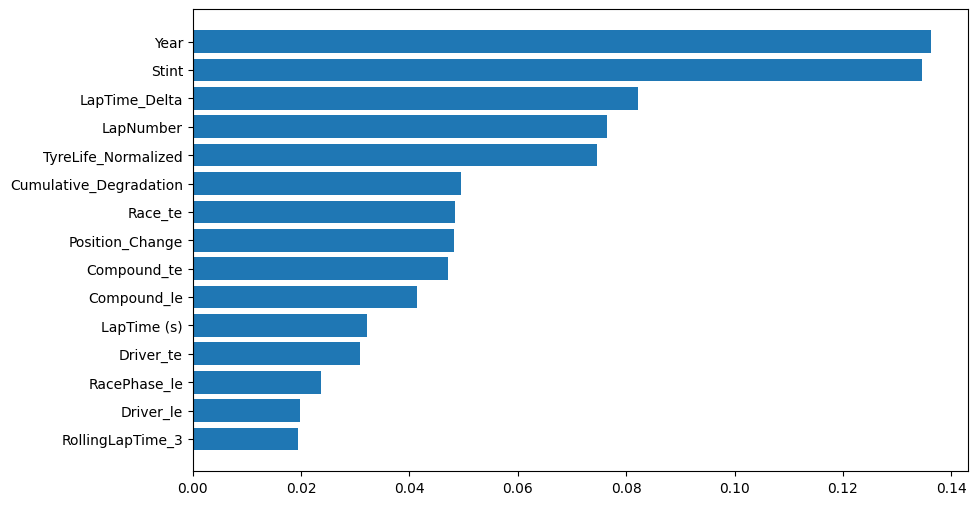

In [ ]:
importance = model.feature_importances_
features = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:15], feat_imp['Importance'][:15])
plt.gca().invert_yaxis()
plt.show()